In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv('telecom_ibm_feature_engineered.csv')
print(df.shape)
df.head()

(7043, 43)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup,CustomerSegment
0,7590-VHVEG,Female,0,Yes,No,1,No,Yes,29.85,29.85,...,False,False,False,False,False,False,True,False,0-1 Yıl,Düşük Değerli Yeni Müşteri
1,5575-GNVDE,Male,0,No,No,34,Yes,No,56.95,1889.50,...,False,False,False,True,False,False,False,True,2-4 Yıl,Düşük Değerli Sadık Müşteri
2,3668-QPYBK,Male,0,No,No,2,Yes,Yes,53.85,108.15,...,False,False,False,False,False,False,False,True,0-1 Yıl,Düşük Değerli Yeni Müşteri
3,7795-CFOCW,Male,0,No,No,45,No,No,42.30,1840.75,...,False,False,False,True,False,False,False,False,2-4 Yıl,Düşük Değerli Sadık Müşteri
4,9237-HQITU,Female,0,No,No,2,Yes,Yes,70.70,151.65,...,False,False,False,False,False,False,True,False,0-1 Yıl,Yüksek Değerli Yeni Müşteri


In [4]:
cluster_features = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Age', 'SupportTicketCount']]
cluster_features.describe()

,tenure,MonthlyCharges,TotalCharges,Age,SupportTicketCount
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,49.351981,1.957405
std,24.559481,30.090047,2266.794470,18.176595,1.666331
min,0.000000,18.250000,0.000000,18.000000,0.000000
25%,9.000000,35.500000,398.550000,34.000000,1.000000
50%,29.000000,70.350000,1394.550000,49.000000,2.000000
75%,55.000000,89.850000,3786.600000,65.000000,3.000000
max,72.000000,118.750000,8684.800000,80.000000,6.000000


In [5]:
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

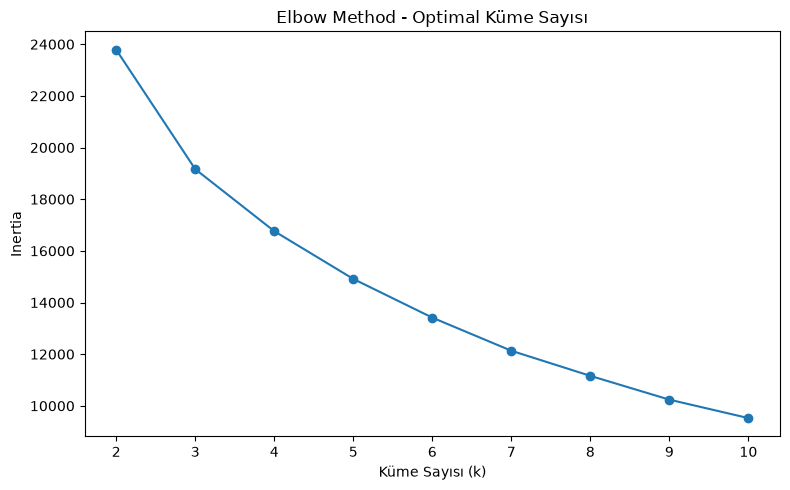

In [6]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal Küme Sayısı')
plt.tight_layout()
plt.savefig('segmentation_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

k=2: Silhouette Score = 0.3055
k=3: Silhouette Score = 0.2632
k=4: Silhouette Score = 0.2473
k=5: Silhouette Score = 0.2476
k=6: Silhouette Score = 0.2299
k=7: Silhouette Score = 0.2322
k=8: Silhouette Score = 0.2368
k=9: Silhouette Score = 0.2364
k=10: Silhouette Score = 0.2374


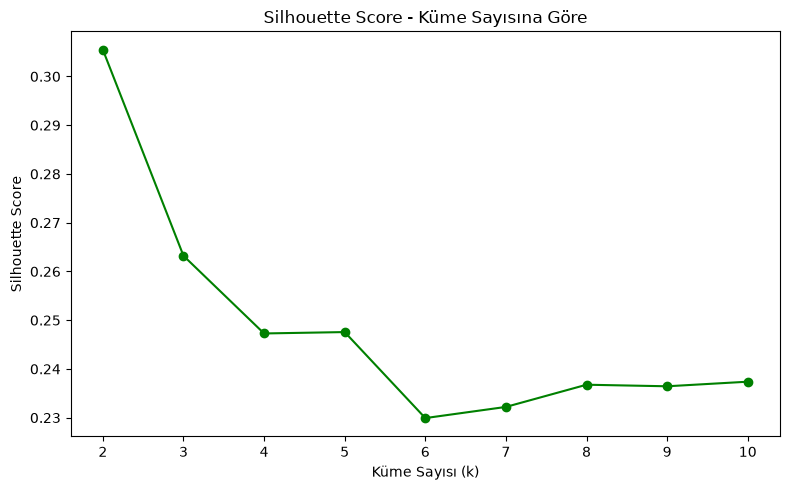

In [7]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_scaled)
    score = silhouette_score(cluster_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Küme Sayısına Göre')
plt.tight_layout()
plt.savefig('segmentation_silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(cluster_scaled)

final_silhouette = silhouette_score(cluster_scaled, df['Cluster'])
print("Final Silhouette Score (k=4):", round(final_silhouette, 4))

df['Cluster'].value_counts().sort_index()

Final Silhouette Score (k=4): 0.2473


Cluster
0    1764
1    2019
2    1609
3    1651
Name: count, dtype: int64

In [9]:
cluster_profile = df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges', 'Age', 'SupportTicketCount']].mean().round(2)
cluster_profile['Musteri_Sayisi'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,tenure,MonthlyCharges,TotalCharges,Age,SupportTicketCount,Musteri_Sayisi
Cluster,,,,,,
0,21.08,49.45,922.17,66.93,1.33,1764
1,59.07,91.64,5397.15,49.82,1.65,2019
2,16.41,74.11,1221.05,44.92,4.00,1609
3,27.33,39.14,949.69,34.32,1.02,1651


In [12]:
print("Kümelere göre Contract dağılımı (%):")
contract_cols = [c for c in df.columns if 'Contract' in c]
print(df.groupby('Cluster')[contract_cols].mean().round(3) * 100)

print("\nKümelere göre Churn oranı (%):")
print((df.groupby('Cluster')['Churn_Binary'].mean() * 100).round(2))

Kümelere göre Contract dağılımı (%):
         Contract_One year  Contract_Two year
Cluster                                      
0                     18.9               17.3
1                     30.3               44.3
2                      9.4                2.4
3                     22.8               27.7

Kümelere göre Churn oranı (%):
Cluster
0    28.06
1    15.30
2    48.73
3    17.02
Name: Churn_Binary, dtype: float64


In [11]:
print([c for c in df.columns if 'Contract' in c])

['Contract_One year', 'Contract_Two year']


In [17]:
cluster_names = {
    0: 'Yaslı Düşük Harcamalı Müşteri',
    1: 'Yüksek Değerli Sadık Müşteri',
    2: 'Yeni Yüksek Riskli Müşteri',
    3: 'Genç Düşük Harcamalı Müşteri'
}

df['SegmentLabel'] = df['Cluster'].map(cluster_names)

segment_results = df[['customerID', 'Cluster', 'SegmentLabel']]
segment_results.to_csv('customer_segments.csv', index=False)
segment_results.head(10)

,customerID,Cluster,SegmentLabel
0,7590-VHVEG,2,Yeni Yüksek Riskli Müşteri
1,5575-GNVDE,0,Yaslı Düşük Harcamalı Müşteri
2,3668-QPYBK,2,Yeni Yüksek Riskli Müşteri
3,7795-CFOCW,3,Genç Düşük Harcamalı Müşteri
4,9237-HQITU,2,Yeni Yüksek Riskli Müşteri
5,9305-CDSKC,2,Yeni Yüksek Riskli Müşteri
6,1452-KIOVK,2,Yeni Yüksek Riskli Müşteri
7,6713-OKOMC,3,Genç Düşük Harcamalı Müşteri
8,7892-POOKP,1,Yüksek Değerli Sadık Müşteri
9,6388-TABGU,1,Yüksek Değerli Sadık Müşteri


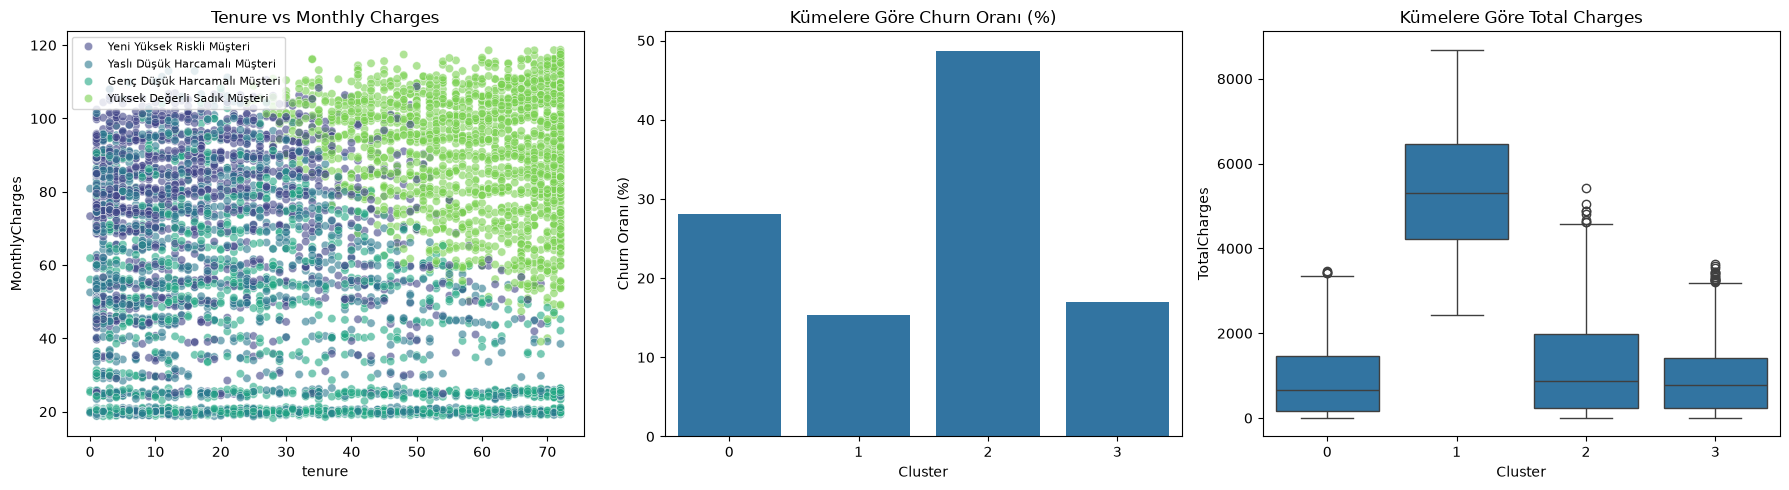

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='SegmentLabel', palette='viridis', ax=axes[0], alpha=0.6)
axes[0].set_title('Tenure vs Monthly Charges')
axes[0].legend(fontsize=8)

sns.barplot(x=df.groupby('Cluster')['Churn_Binary'].mean().index, 
            y=df.groupby('Cluster')['Churn_Binary'].mean().values * 100, 
            ax=axes[1])
axes[1].set_title('Kümelere Göre Churn Oranı (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Churn Oranı (%)')

sns.boxplot(data=df, x='Cluster', y='TotalCharges', ax=axes[2])
axes[2].set_title('Kümelere Göre Total Charges')

plt.tight_layout()
plt.savefig('segmentation_clusters_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
cluster_profile = df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges', 'Age', 'SupportTicketCount']].mean().round(2)
cluster_profile['Musteri_Sayisi'] = df['Cluster'].value_counts().sort_index()
cluster_profile['SegmentLabel'] = cluster_profile.index.map(cluster_names)
cluster_profile.to_csv('segmentation_cluster_profile.csv')
cluster_profile

cluster_summary = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'SegmentLabel': [cluster_names[i] for i in range(4)],
    'ChurnRate_%': (df.groupby('Cluster')['Churn_Binary'].mean() * 100).round(2).values,
    'OneYear_Contract_%': df.groupby('Cluster')['Contract_One year'].mean().round(3).values * 100,
    'TwoYear_Contract_%': df.groupby('Cluster')['Contract_Two year'].mean().round(3).values * 100,
    'Silhouette_Score': [final_silhouette] * 4
})
cluster_summary.to_csv('segmentation_summary.csv', index=False)
cluster_summary

segmentation_model_result = pd.DataFrame({
    'ModelName': ['Customer Segmentation'],
    'Algorithm': ['KMeans'],
    'NumberOfClusters': [4],
    'SilhouetteScore': [round(final_silhouette, 4)],
    'TrainDate': [pd.Timestamp.now().strftime('%Y-%m-%d')]
})
segmentation_model_result.to_csv('segmentation_model_performance.csv', index=False)
segmentation_model_result

import joblib
joblib.dump(kmeans_final, 'kmeans_segmentation_model.pkl')
joblib.dump(scaler, 'segmentation_scaler.pkl')
print("Model ve scaler kaydedildi.")

Model ve scaler kaydedildi.
